In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("bank.csv")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [8]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(11162, 17)

In [11]:
df.nunique().sum()

np.int64(5928)

In [12]:
df["poutcome"].unique()

array(['unknown', 'other', 'failure', 'success'], dtype=object)

In [13]:
x_count=df[df.columns[[0,5,9,11,12,13,14]]]
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss_x=ss.fit_transform(x_count)
ss_x=pd.DataFrame(ss_x)
ss_x.columns=list(df.columns[[0,5,9,11,12,13,14]])
ss_x



,age,balance,day,duration,campaign,pdays,previous
0,1.491505,0.252525,-1.265746,1.930226,-0.554168,-0.481184,-0.363260
1,1.239676,-0.459974,-1.265746,3.154612,-0.554168,-0.481184,-0.363260
2,-0.019470,-0.080160,-1.265746,2.929901,-0.554168,-0.481184,-0.363260
3,1.155733,0.293762,-1.265746,0.596366,-0.554168,-0.481184,-0.363260
4,1.071790,-0.416876,-1.265746,0.867171,-0.186785,-0.481184,-0.363260
...,...,...,...,...,...,...,...
11157,-0.691015,-0.473616,0.515650,-0.331287,-0.554168,-0.481184,-0.363260
11158,-0.187357,-0.246658,0.040612,-0.832564,0.547981,-0.481184,-0.363260
11159,-0.774958,-0.464934,0.396891,-0.622258,-0.186785,-0.481184,-0.363260
11160,0.148416,-0.473926,-0.909466,-1.045752,-0.186785,1.109571,1.818332


In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for col in df.columns[[1,2,3,4,6,7,8,10,15,16]]:
    df[col]=le.fit_transform(df[col])
df.head()
   
    

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [15]:

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = df[col].apply(
        lambda x: lower if x < lower else upper if x > upper else x
    )

print(df.head())

    age  job  marital  education  default  balance  housing  loan  contact  \
0  59.0    0        1          1      0.0   2343.0        1   0.0        2   
1  56.0    0        1          1      0.0     45.0        0   0.0        2   
2  41.0    9        1          1      0.0   1270.0        1   0.0        2   
3  55.0    7        1          1      0.0   2476.0        1   0.0        2   
4  54.0    0        1          2      0.0    184.0        0   0.0        2   

   day  month  duration  campaign  pdays  previous  poutcome  deposit  
0    5      8    1033.0       1.0   -1.0       0.0       3.0        1  
1    5      8    1033.0       1.0   -1.0       0.0       3.0        1  
2    5      8    1033.0       1.0   -1.0       0.0       3.0        1  
3    5      8     579.0       1.0   -1.0       0.0       3.0        1  
4    5      8     673.0       2.0   -1.0       0.0       3.0        1  


<Figure size 4000x4000 with 0 Axes>

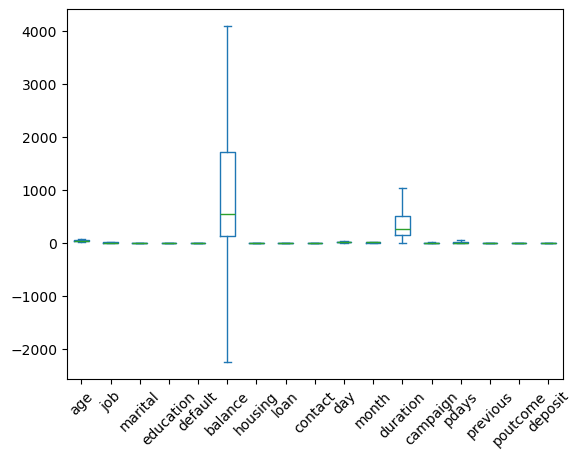

In [16]:
plt.figure(figsize=(40,40))
df.plot(kind='box')
plt.xticks(rotation=45)
plt.show()

In [17]:
df_cat = df[df.columns[[1,2,3,4,6,7,8,10,15,16]]]

df_new = pd.concat([ss_x,df_cat],axis=1)
df_new

,age,balance,day,duration,campaign,pdays,previous,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
0,1.491505,0.252525,-1.265746,1.930226,-0.554168,-0.481184,-0.363260,0,1,1,0.0,1,0.0,2,8,3.0,1
1,1.239676,-0.459974,-1.265746,3.154612,-0.554168,-0.481184,-0.363260,0,1,1,0.0,0,0.0,2,8,3.0,1
2,-0.019470,-0.080160,-1.265746,2.929901,-0.554168,-0.481184,-0.363260,9,1,1,0.0,1,0.0,2,8,3.0,1
3,1.155733,0.293762,-1.265746,0.596366,-0.554168,-0.481184,-0.363260,7,1,1,0.0,1,0.0,2,8,3.0,1
4,1.071790,-0.416876,-1.265746,0.867171,-0.186785,-0.481184,-0.363260,0,1,2,0.0,0,0.0,2,8,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,-0.691015,-0.473616,0.515650,-0.331287,-0.554168,-0.481184,-0.363260,1,2,0,0.0,1,0.0,0,0,3.0,0
11158,-0.187357,-0.246658,0.040612,-0.832564,0.547981,-0.481184,-0.363260,7,1,1,0.0,0,0.0,2,6,3.0,0
11159,-0.774958,-0.464934,0.396891,-0.622258,-0.186785,-0.481184,-0.363260,9,2,1,0.0,0,0.0,0,1,3.0,0
11160,0.148416,-0.473926,-0.909466,-1.045752,-0.186785,1.109571,1.818332,9,1,1,0.0,0,0.0,0,8,0.5,0


In [18]:
df_new

,age,balance,day,duration,campaign,pdays,previous,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
0,1.491505,0.252525,-1.265746,1.930226,-0.554168,-0.481184,-0.363260,0,1,1,0.0,1,0.0,2,8,3.0,1
1,1.239676,-0.459974,-1.265746,3.154612,-0.554168,-0.481184,-0.363260,0,1,1,0.0,0,0.0,2,8,3.0,1
2,-0.019470,-0.080160,-1.265746,2.929901,-0.554168,-0.481184,-0.363260,9,1,1,0.0,1,0.0,2,8,3.0,1
3,1.155733,0.293762,-1.265746,0.596366,-0.554168,-0.481184,-0.363260,7,1,1,0.0,1,0.0,2,8,3.0,1
4,1.071790,-0.416876,-1.265746,0.867171,-0.186785,-0.481184,-0.363260,0,1,2,0.0,0,0.0,2,8,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,-0.691015,-0.473616,0.515650,-0.331287,-0.554168,-0.481184,-0.363260,1,2,0,0.0,1,0.0,0,0,3.0,0
11158,-0.187357,-0.246658,0.040612,-0.832564,0.547981,-0.481184,-0.363260,7,1,1,0.0,0,0.0,2,6,3.0,0
11159,-0.774958,-0.464934,0.396891,-0.622258,-0.186785,-0.481184,-0.363260,9,2,1,0.0,0,0.0,0,1,3.0,0
11160,0.148416,-0.473926,-0.909466,-1.045752,-0.186785,1.109571,1.818332,9,1,1,0.0,0,0.0,0,8,0.5,0


In [19]:
##logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score

X=df.drop('deposit', axis=1)
y=df['deposit']

X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.3, random_state=42)

model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

train_score=model.score(X_train,y_train)
test_score=model.score(X_test,y_test)

accuracy = accuracy_score(y_test,y_pred)
precision= precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("trainng score:", train_score)
print("test_score:", test_score)
print("accuracy_score:", accuracy)
print(" precision:", precision)
print("recall:", recall)
print("f1:", f1)




trainng score: 0.7950851145526686
test_score: 0.7894893998208421
accuracy_score: 0.7894893998208421
 precision: 0.7891025641025641
recall: 0.7660236465463597
f1: 0.7773918534891064


C:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
##logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score

X=df.drop('deposit', axis=1)
y=df['deposit']

X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.3, random_state=42)

model=LogisticRegression(max_iter=1000)

param_grid={
    'C':[10,20,30],
    'solver':['liblinear','lbfgs']
}
gridsearch=GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gridsearch.fit(X_train,y_train)

print("best paramaters:", gridsearch.best_params_)
print("best scoring:", gridsearch.best_score_)

best_model=gridsearch.best_estimator_

y_pred=best_model.predict(X_test)

train_score=best_model.score(X_train,y_train)
test_score=best_model.score(X_test,y_test)

accuracy = accuracy_score(y_test,y_pred)
precision= precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("trainng score:", train_score)
print("test_score:", test_score)
print("accuracy_score:", accuracy)
print(" precision:", precision)
print("recall:", recall)
print("f1:", f1)



best paramaters: {'C': 10, 'solver': 'liblinear'}
best scoring: 0.8023830530440247
trainng score: 0.8046845001919877
test_score: 0.7951627351448194
accuracy_score: 0.7951627351448194
 precision: 0.8117806364251862
recall: 0.746110765401369
f1: 0.7775616083009079


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score,precision_score,recall_score
from sklearn.model_selection import train_test_split

X=df.drop('deposit', axis=1)
y=df['deposit']

X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.3, random_state=42)

model=DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

train_score=model.score(X_train,y_train)
test_score=model.score(X_test,y_test)

accuracy=accuracy_score(y_pred,y_test)
f1=f1_score(y_pred,y_test)
precision=precision_score(y_pred,y_test)
recall=recall_score(y_pred,y_test)

print("train_score:", train_score)
print("test_score:",test_score)
print("accuracy_score:",accuracy)
print("f1_score:",f1)
print("precision_score:",precision)
print("recall_score:",recall)


train_score: 1.0
test_score: 0.7778441325768887
accuracy_score: 0.7778441325768887
f1_score: 0.767935121646912
precision_score: 0.7660236465463597
recall_score: 0.7698561601000625


In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score,precision_score,recall_score
from sklearn.model_selection import train_test_split

X=df.drop('deposit', axis=1)
y=df['deposit']

X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.3, random_state=42)

model=SVC()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

train_score=model.score(X_train,y_train)
test_score=model.score(X_test,y_test)

accuracy=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)

print("train_score:", train_score)
print("test_score:",test_score)
print("accuracy_score:",accuracy)
print("f1_score:",f1)
print("precision_score:",precision)
print("recall_score:",recall)


train_score: 0.7515678996544222
test_score: 0.7467900865930128
accuracy_score: 0.7467900865930128
f1_score: 0.7250324254215305
precision_score: 0.7569397427217333
recall_score: 0.6957062850031114
